# Edgelist Network Analysis and Epidemic Modeling

## Introduction

This notebook demonstrates how to work with **real-world network data** loaded from edgelist files in the epidemic modeling workflow.

We will:

- **Load a network from an edgelist file**
- **Integrate it with the existing workflow functions**
- **Analyze network properties** (degree distribution, centrality measures, etc.)
- **Run epidemic simulations** on the real network data
- **Compare with synthetic network types**

This approach allows you to study epidemic dynamics on empirical network structures, such as social networks, contact networks, or transportation networks.

## Setup

First, we'll set up the environment and create necessary directories for storing results.

In [82]:
# Navigate to the directory containing this file
cd(@__DIR__)

# Create directories if they don't exist
if !isdir("data")
    mkdir("data")
end
if !isdir("figures")
    mkdir("figures")
end
if !isdir("output")
    mkdir("output")
end

Next, we activate the current directory as the environment for Pkg and import the required packages. This includes the additional `GraphIO.EdgeList` package for loading edgelist files.

In [83]:
# Import the Pkg module, activate the current directory as the environment for Pkg, instantiate the environment
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

# Import the necessary packages
using Agents, Graphs, Random, Plots, DataFrames, CSV, CategoricalArrays, Statistics, StatsBase, StatsPlots, Distributions, Measures, Optim
using GraphIO.EdgeList, GraphPlot

  Activating project at `c:\Users\leost\julia-workspace\espidam-tutorial-2025`


## Model Definition

Now we'll set up the epidemic model using the same modular approach as in the other tutorials. The model components are defined in separate source files for modularity and reusability.

The edgelist network will be loaded automatically during model initialization, ensuring consistency with the workflow.

In [84]:
include("src/create_graph.jl")

# Agent creation: agents of type Person and properties status, days_infected and risk
@agent struct Person(GraphAgent)
    status::Symbol = :S #((S)usceptible, (I)nfected, (R)ecovered)
    days_infected::Int = 0 # number of days since infection
    risk::Symbol = :high # something to differentiate agents (here, high and low risk)
end

include("src/initialize.jl")
include("src/agent_step.jl")

# Model step: keep track of the infection numbers
function model_step!(model::ABM)
    model.susceptible_count = sum([model[i].status == :S for i in 1:nv(model.graph)])
    model.infected_count = sum([model[i].status == :I for i in 1:nv(model.graph)])
    model.recovered_count = sum([model[i].status == :R for i in 1:nv(model.graph)])
end

model_step! (generic function with 1 method)

## Model Initialization with Edgelist Network

We'll initialize the model using the `:edgelist` network type, which integrates seamlessly with the existing workflow. The initialization function will automatically load the edgelist file and set up the model with the appropriate network properties.

In [85]:
# Initialize the model using the edgelist network type
# The create_graph function will handle file conversion automatically
model = initialize(
    network_type = :edgelist,
    edgelist_path = "degs/2000.txt",  # Use the original .txt file - it will be converted automatically
    patient_zero = :random,
    high_risk = :random,
    fraction_high_risk = 0.1,
    trans_prob = 0.1,
    days_to_recovered = 14,
    seed = 42,
    low_risk_factor = 1.0
)

println("Model initialized with $(model.n_nodes) agents (network type: $(model.network_type), mean degree: ~$(model.mean_degree))")

Model initialized with 1860 agents (network type: edgelist, mean degree: ~5)


## Network Analysis

Now we can analyze the network structure using the regular workflow functions. This includes calculating various network metrics and centrality measures.

In [86]:
include("src/analyze_graph.jl")
include("src/plotting.jl")

# Analyze the graph
println("Analyzing the edgelist network...")
graph_analysis = analyze_graph(model.graph)

display(graph_analysis["summary"])

display(first(graph_analysis["centrality"], 10))

Row,metric,value
,String,Any
1,Mean Degree,4.55054
2,Density,0.00244784
3,Clustering Coefficient,0.211647
4,Assortativity,0.0120561
5,Diameter,Graph is not connected
6,Number of Connected Components,15
7,Max Component Length,1845


Row,node_id,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality
,Int64,Float64,Float64,Float64,Float64
1,1,0.00591716,0.00248982,0.146505,0.160516
2,2,0.00215169,0.000280244,0.129039,0.0475961
3,3,0.00968263,0.0067841,0.146811,0.234055
4,4,0.00161377,3.18561e-6,0.114406,0.0225623
5,5,0.00484131,0.0037977,0.150421,0.151755
6,6,0.00161377,0.000365008,0.120345,0.0487948
7,7,0.00161377,0.0,0.130885,0.0672135
8,8,0.000537924,0.0,0.114621,0.00929914
9,9,0.00268962,3.37235e-5,0.130923,0.0893243


Analyzing the edgelist network...


In [87]:
# Save the analysis to CSV files
CSV.write("data/graph_summary_$(model.network_type)_mdeg_$(model.mean_degree).csv", graph_analysis["summary"])
CSV.write("data/centrality_$(model.network_type)_mdeg_$(model.mean_degree).csv", graph_analysis["centrality"])

println("Analysis results saved to data/ directory")

Analysis results saved to data/ directory


## Epidemic Simulation

Let's run an epidemic simulation on the edgelist network and visualize the dynamics.

In [88]:
# Run a single simulation to test dynamics
println("Running epidemic simulation...")
adata = [:status]
mdata = [:susceptible_count, :infected_count, :recovered_count]
adf, mdf = run!(model, 100; adata, mdata)

println("Simulation completed! Final outbreak size: $(mdf[end, :recovered_count])/$(model.n_nodes) ($(round(100 * mdf[end, :recovered_count] / model.n_nodes, digits=1))%)")

Running epidemic simulation...
Simulation completed! Final outbreak size: 1469/1860 (79.0%)


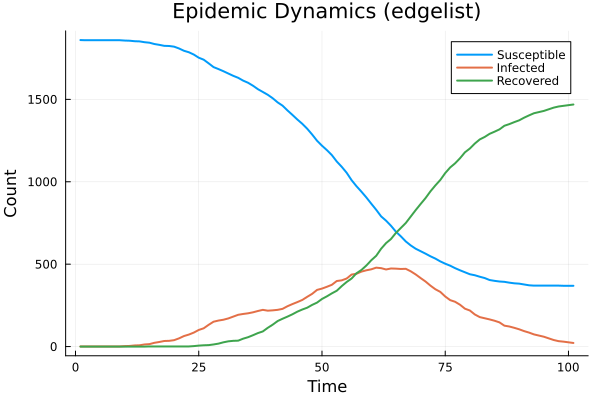

Dynamics plot saved to figures/ directory


In [89]:
# Plot the epidemic dynamics
dynamics_plot = plot_epidemic_trajectories(mdf, model.network_type)
display(dynamics_plot)
savefig(dynamics_plot, "figures/dynamics_$(model.network_type)_mdeg_$(model.mean_degree).pdf")

println("Dynamics plot saved to figures/ directory")

## Network Comparison

One of the advantages of integrating edgelist networks into the regular workflow is the ability to compare them with synthetic network types. Let's compare our edgelist network with random and small-world networks.

Analyzing random network...
Analyzing smallworld network...
Analyzing edgelist network...
Saving network metrics comparison plot to figures/network_metrics_comparison_random_smallworld_edgelist_mdeg_5.pdf
Network comparison completed with 1860 nodes for all network types!


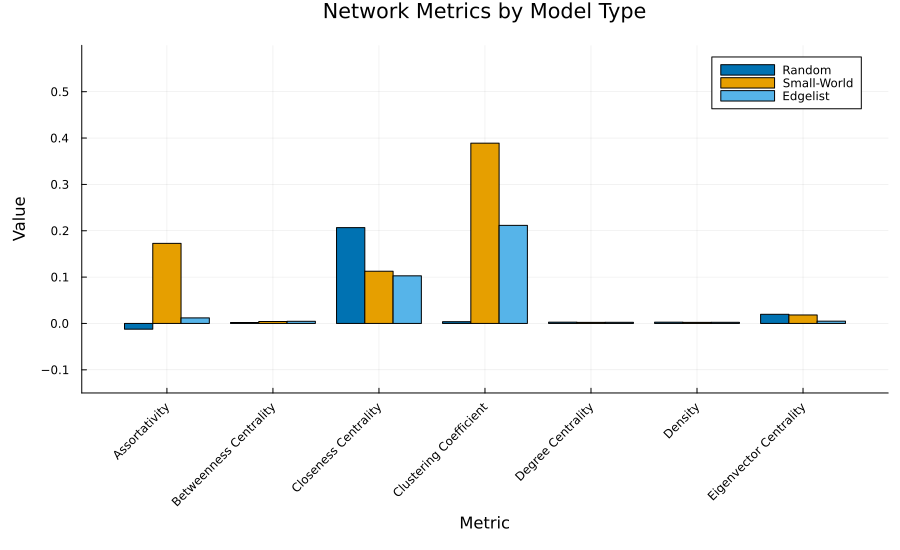

In [90]:
# Compare network metrics across different network types
# Use the same number of nodes as the edgelist network for fair comparison
include("src/plotting.jl")

comparison_plot = plot_network_metrics_comparison(
    network_types=[:random, :smallworld, :edgelist], 
    mean_degree=model.mean_degree, 
    n_nodes=model.n_nodes  # Use actual edgelist network size
)

display(comparison_plot)
println("Network comparison completed with $(model.n_nodes) nodes for all network types!")


Generating centrality comparison for network structure analysis...
Saving combined centrality comparison plot to figures/centrality_comparison_random_smallworld_preferential_edgelist_mdeg_5.pdf
Centrality comparison completed! Results saved to figures/ directory.


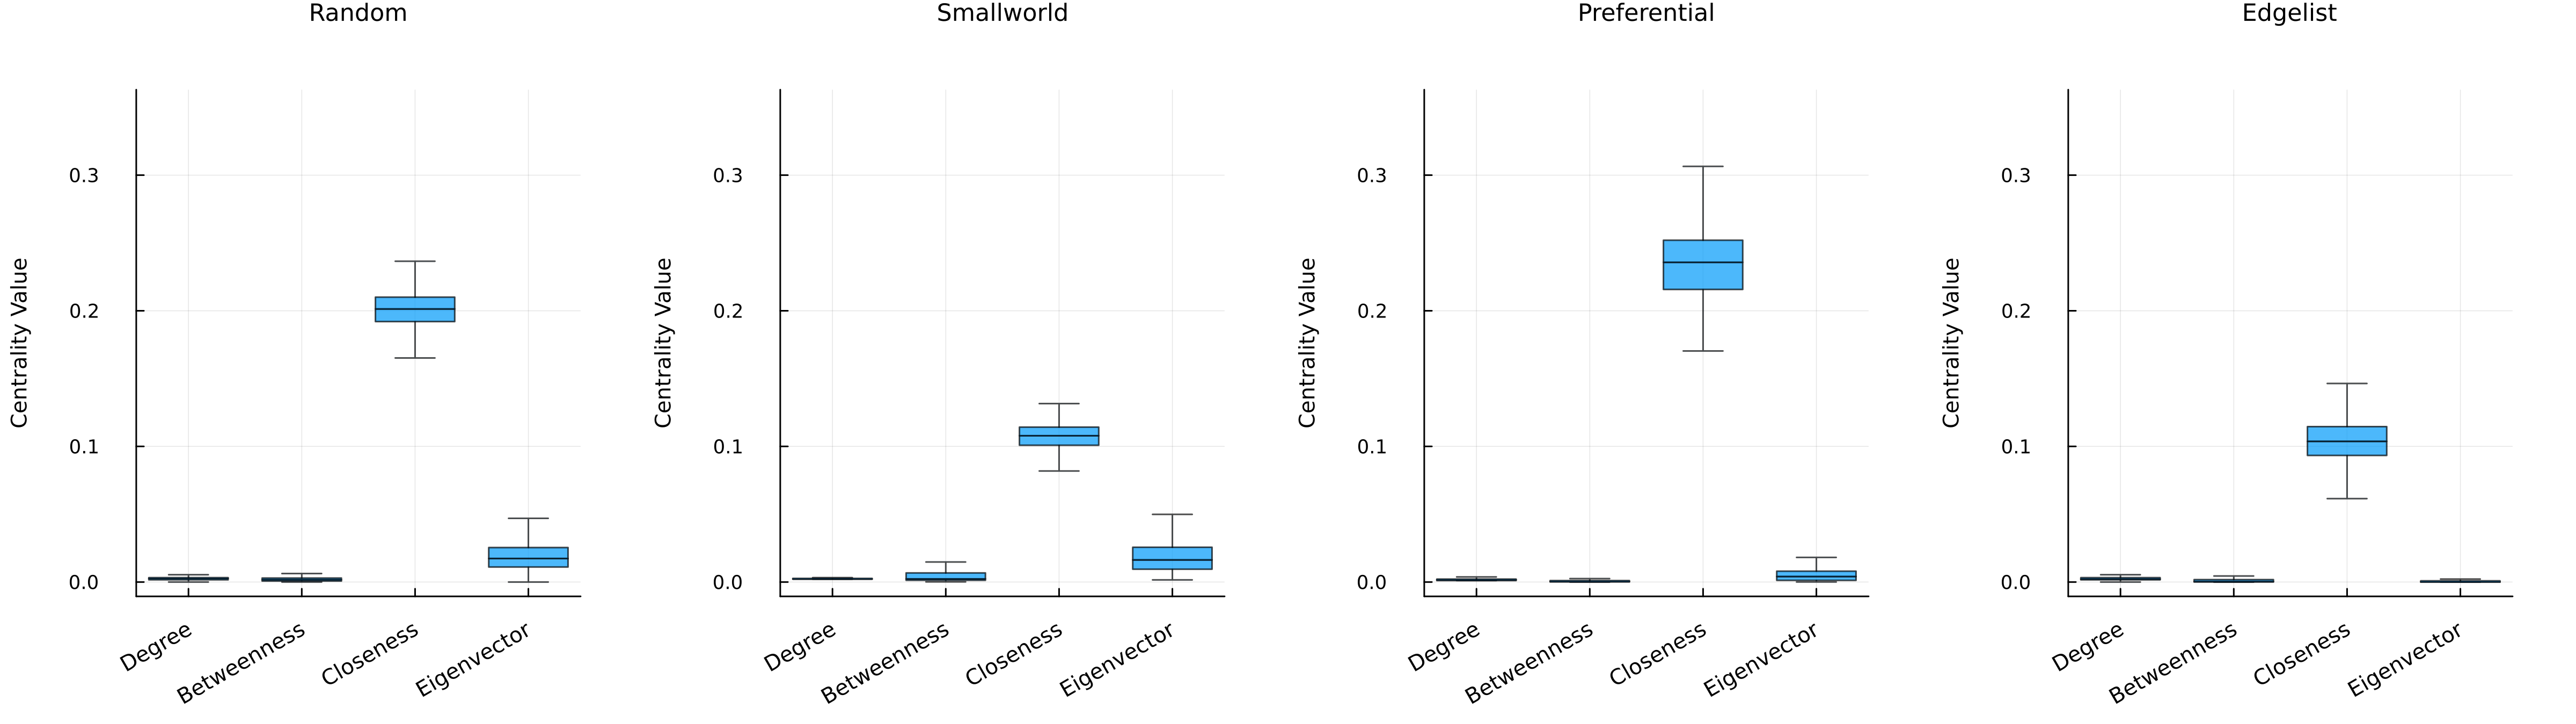

In [91]:
# Also generate centrality comparison for the same network types
println("\nGenerating centrality comparison for network structure analysis...")
centrality_comparison = plot_centrality_comparison(
    network_types = [:random, :smallworld, :preferential, :edgelist],
    mean_degree = model.mean_degree,
    n_nodes = model.n_nodes,
    link_axes = true
)

display(centrality_comparison)
println("Centrality comparison completed! Results saved to figures/ directory.")

## Epidemic Comparison

Now let's run multiple epidemic simulations to compare the dynamics across different network types. This will show how the network structure affects epidemic spread patterns.

Running epidemic comparison between network types...
This may take a few minutes as it runs multiple simulations...
Running simulations for random network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Running simulations for smallworld network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Running simulations for preferential network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Running simulations for edgelist network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Saving combined comparison plot to figures/combined_comparison_mdeg_5.pdf
Epidemic comparison completed! Results saved to figures/ and output/ directories.


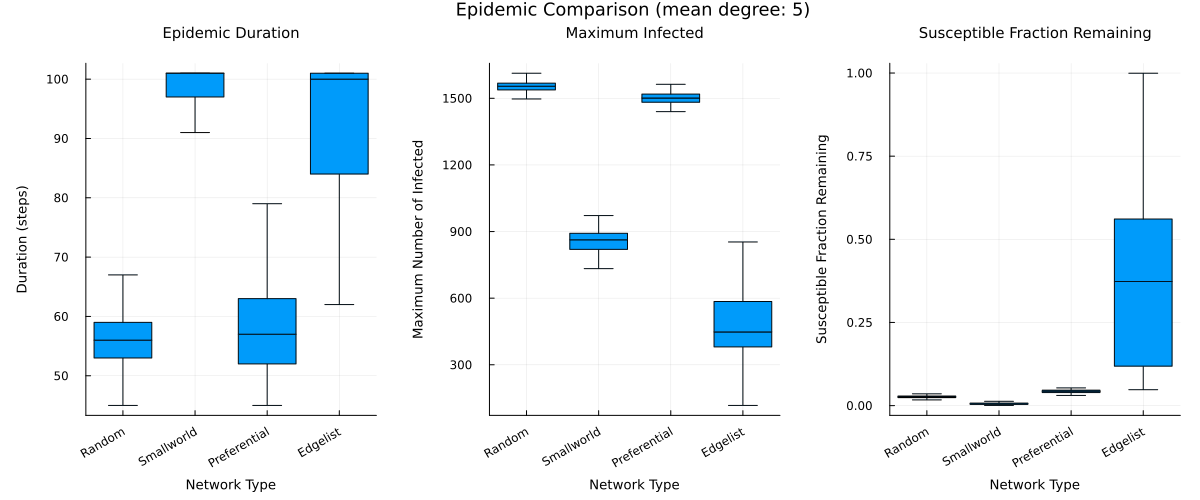

In [92]:
# Load the run_simulations function needed for epidemic comparison
include("src/run_simulations.jl")
include("src/plotting.jl")

# Run epidemic comparison across network types
println("Running epidemic comparison between network types...")
println("This may take a few minutes as it runs multiple simulations...")

# Note: Proportionate mixing networks may have issues with small network sizes
epidemic_comparison = run_and_plot_comparison(
    network_types = [:random, :smallworld, :preferential, :edgelist],
    mean_degree = model.mean_degree,
    n_nodes = model.n_nodes,
    trans_prob = 0.1,
    n_steps = 100
)

display(epidemic_comparison)
println("Epidemic comparison completed! Results saved to figures/ and output/ directories.")